# Dog breeds recogniztion

In [47]:
import sys
import os

sys.path.append(os.path.abspath("../src"))

In [2]:
from preprocessing import preprocess_data
from pathlib import Path
import cv2
import matplotlib.pyplot as plt
import numpy as np

In this Project we will use Stanford Dogs dataset.

First we preprocess our data. Here we:
- resize the image
- reshape the vector with images, so each sample is a vector with $64*64*3$ parameters

In [3]:
X, y = preprocess_data(path_to_data = "data", img_size = 64, n_class = 3, n_samples_in_class = 150)

In [4]:
X.shape

(450, 12288)

# Creating pipeline

First we will standarize our data $((x - \mu)/\sigma)$. (PCA provides centering, but not scaling.)

In [5]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

We will use principal component analysis to extract more meaningful features. Fro now we will reduce the number of components to 100. 

In [6]:
from sklearn.decomposition import PCA
pca = PCA(n_components=100, svd_solver = "randomized", whiten = True, random_state=44)
#setting whiten = True forces the SVM to disfavor components with higher variance

For recognizing breeds we will use Support Vector Machine algorithm.

In [7]:
from sklearn.svm import SVC
svc = SVC(kernel = "rbf")

We pack scaler, PCA and SVM into a single pipeline.

In [8]:
from sklearn.pipeline import Pipeline
model = Pipeline(
    [('scaler', scaler),
     ('pca', pca),
     ('svc', svc)])

# Training - first try

We divide our data into training and testing sets.

In [9]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 44)

In [10]:
X_train.shape

(360, 12288)

In [11]:
y_train.shape

(360,)

We train our pipeline and get the accuracy score.

In [12]:
model.fit(X_train, y_train)
print("Accuracy: ", model.score(X_test, y_test))

Accuracy:  0.4777777777777778


# Adding bounding boxes

We now add bounding boxes to remove all unnecessary elements from the image except the dog. Annotations containing the bounding boxes have been included in the dataset.

In [13]:
X_bounded, y_bounded = preprocess_data(path_to_data = "data", img_size = 64, n_class = 3, n_samples_in_class = 150, crop = True)

In [14]:
X_bounded.shape

(450, 12288)

In [15]:
Xb_train, Xb_test, yb_train, yb_test = train_test_split(X_bounded, y_bounded, test_size = 0.2, random_state = 44)

In [16]:
model.fit(Xb_train, yb_train)
print("Accuracy: ", model.score(Xb_test, yb_test))

Accuracy:  0.5444444444444444


The model accuracy improved slightly.

# Expanding dataset

Finally we will expand out dataset by adding mirror reflections of each photo.

First we preprocess data by cropping images. This time we do not flatten images inside the `preprocess_data` function, because function `expand_dataset` operate on non-flatten images.

In [17]:
X_expanded, y_expanded = preprocess_data(path_to_data = "data", img_size = 64, n_class = 3, n_samples_in_class = 150, crop = True, flatten = False)

Now we get training sets, so we can then expand them. We do not expand test sets, because we don't want to test our model on two images where one is the mirror reflection of the other.

In [18]:
X_exp_train, _ , y_exp_train, _ = train_test_split(X_expanded, y_expanded, test_size = 0.2, random_state = 44)

In [19]:
from preprocessing import expand_dataset

In [20]:
X_exp_train, y_exp_train = expand_dataset(X_exp_train, y_exp_train)

In [21]:
X_exp_train = X_exp_train.reshape(X_exp_train.shape[0], -1) #here we flatten the data

In [22]:
X_exp_train.shape

(720, 12288)

In [23]:
model.fit(X_exp_train, y_exp_train)
print("Accuracy: ", model.score(Xb_test, yb_test)) #we test our model

Accuracy:  0.5888888888888889


# Searching for best parameters

We use grid search cross validation to find best combination of parameters. Here we will adjust:
- ``n_components`` (which determines a number of principal components chosen by PCA)
- ``C`` (which controls the margin hardness)
- ``gamma`` (which controls the size of the radial basis function kernel)

In [24]:
from sklearn.model_selection import GridSearchCV

param_grid = {'pca__n_components': [120 ,150, 170, 200],
             'svc__C': [0.1, 0.5, 1, 2],
             'svc__gamma' : [0.0001,0.0005,0.001, 0.005]}

grid = GridSearchCV(model, param_grid)
grid.fit(X_exp_train, y_exp_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...svc', SVC())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'pca__n_components': [120, 150, ...], 'svc__C': [0.1, 0.5, ...], 'svc__gamma': [0.0001, 0.0005, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is 

In [25]:
print(grid.best_params_)
print(grid.best_score_)

{'pca__n_components': 150, 'svc__C': 1, 'svc__gamma': 0.001}
0.6597222222222223


In [26]:
model = grid.best_estimator_
print("Accuracy: ", model.score(Xb_test, yb_test))

Accuracy:  0.5333333333333333


# Visualizing model mistakes

In [27]:
model = grid.best_estimator_

In [28]:
yfit = model.predict(Xb_test)

In [29]:
X_show_img, y_show_img = preprocess_data(path_to_data = "data", img_size = 256, n_class = 3, n_samples_in_class = 150, crop =True, flatten = False)

In [30]:
Ximg_train, Ximg_test, yimg_train, yimg_test = train_test_split(X_show_img, y_show_img, test_size = 0.2, random_state = 44)

In [31]:
n_images = 25
indexes = np.array([i for i in range(0, Ximg_test.shape[0], round((Ximg_test.shape[0]/n_images)))])
images = np.array([Ximg_test[i] for i in indexes])

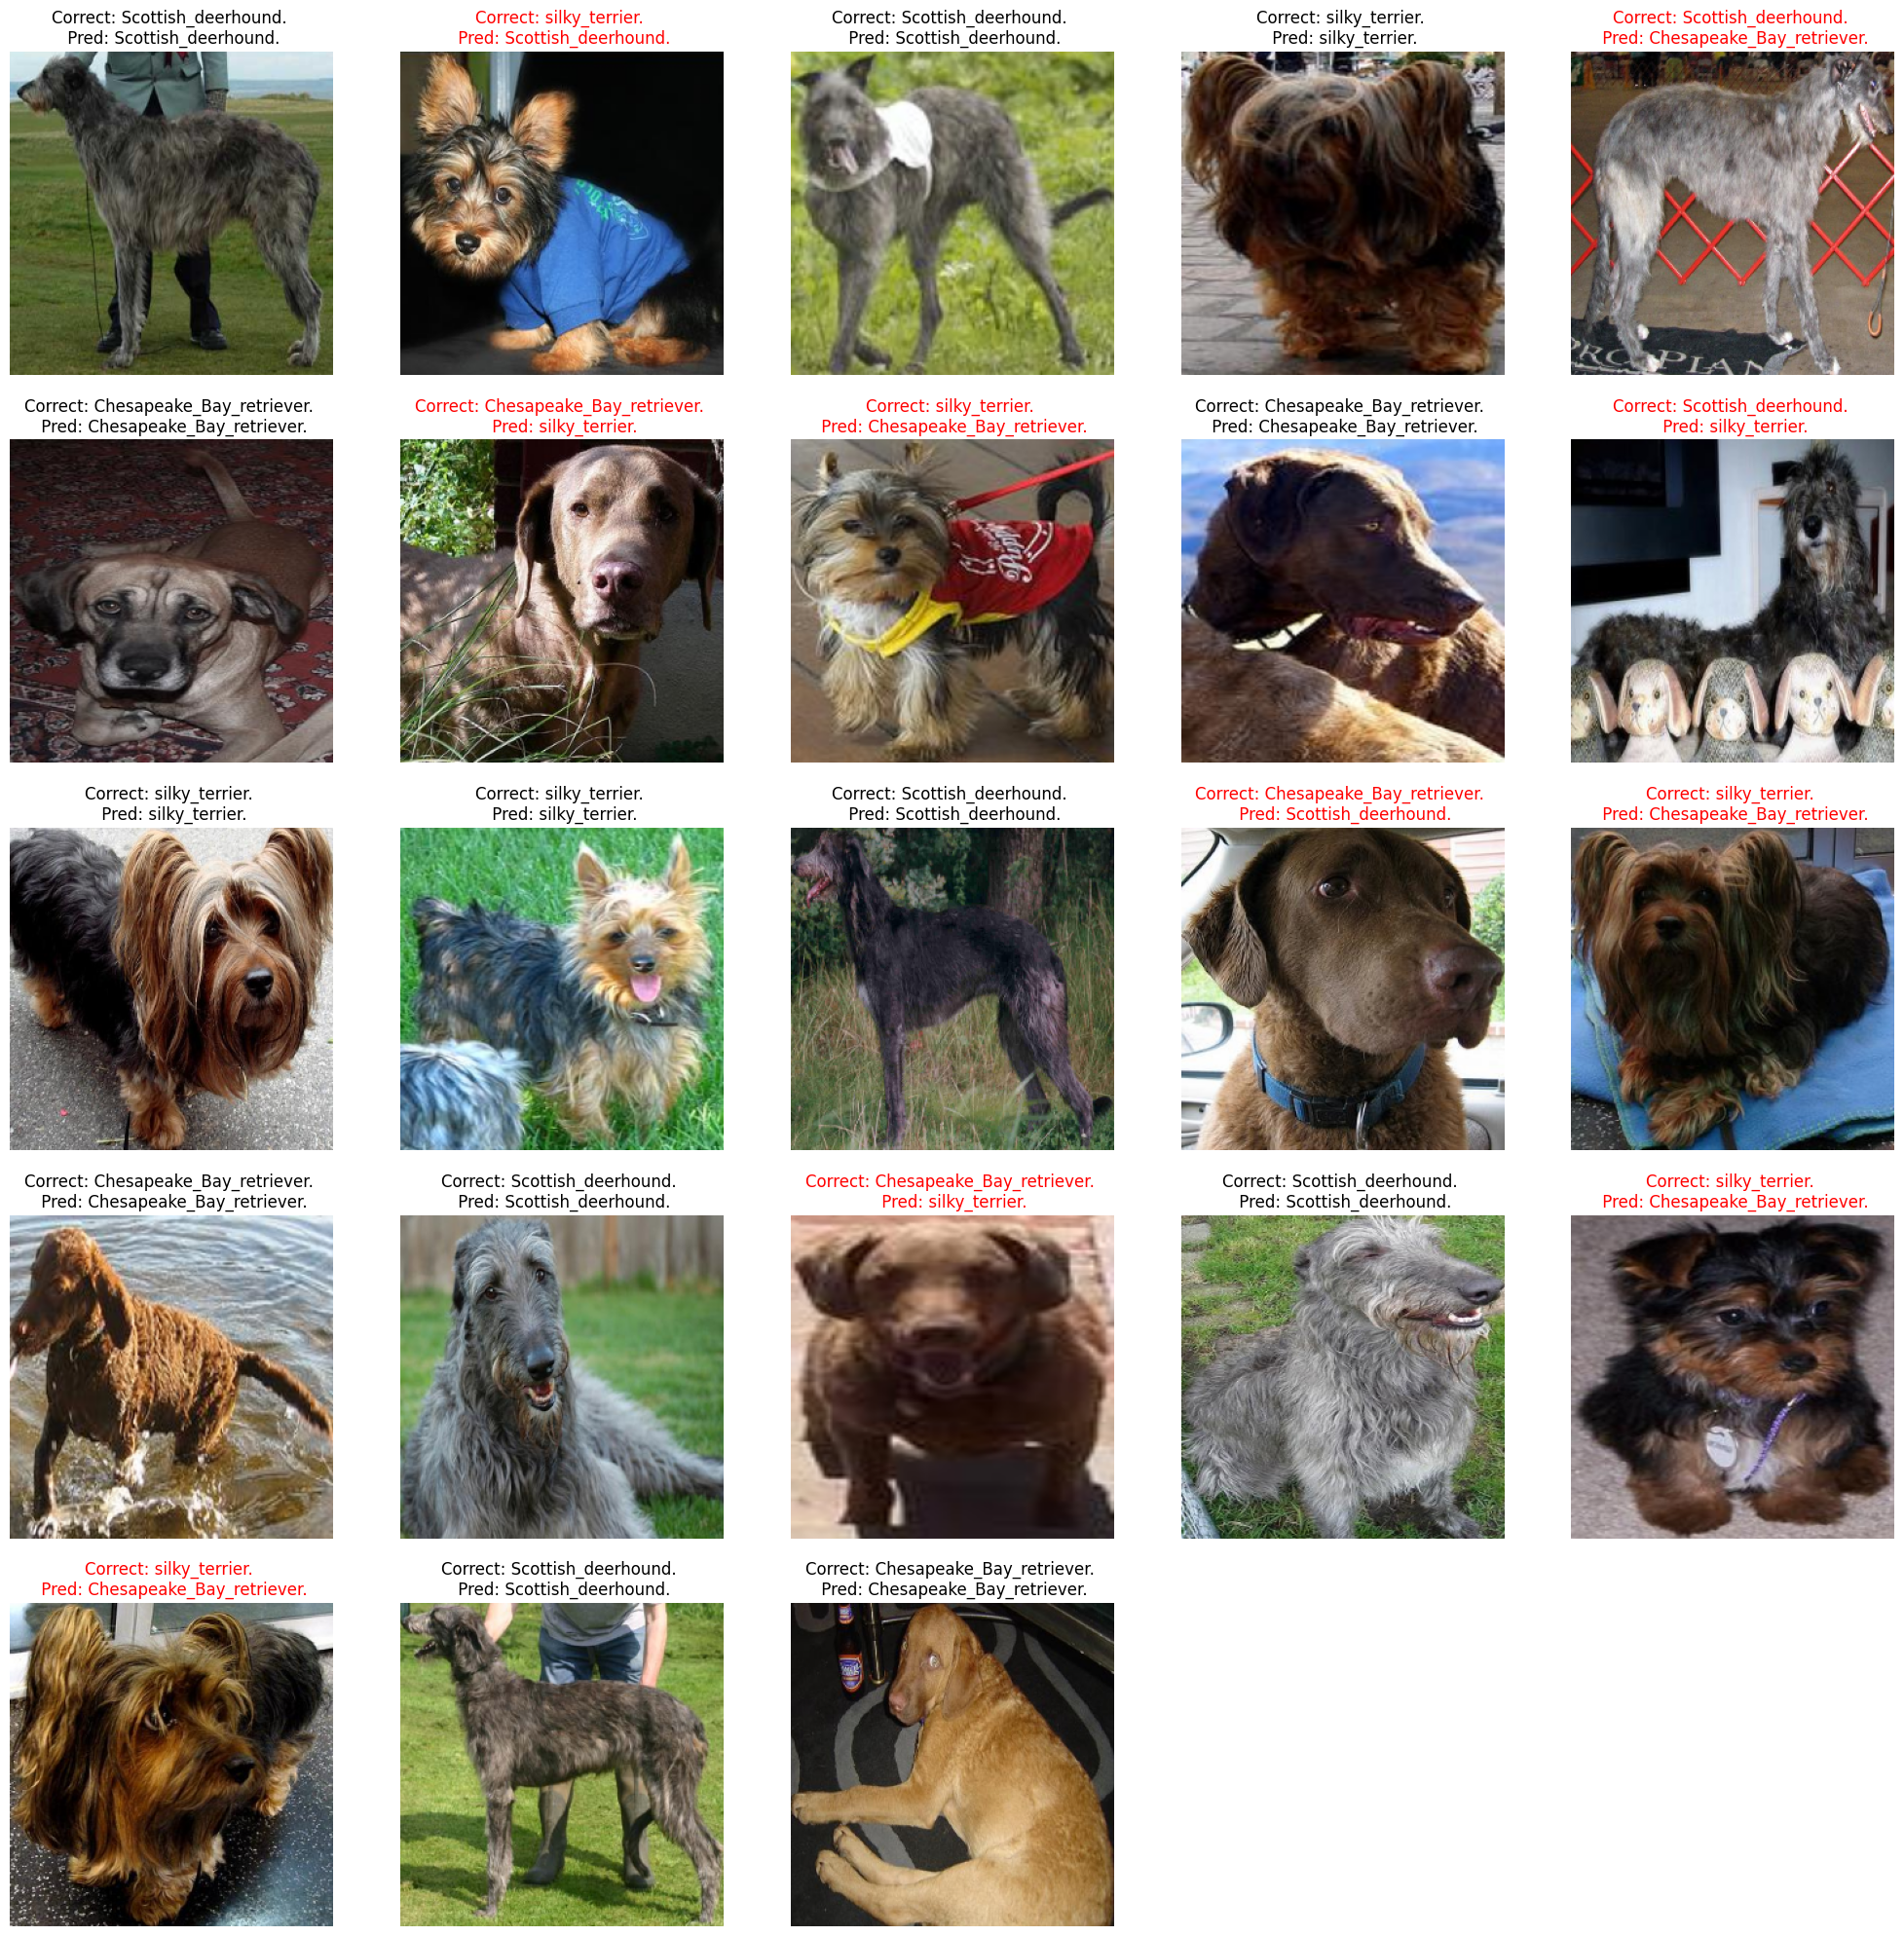

In [32]:
cols = 5
rows = 5

plt.figure(figsize = (5*cols,5*rows))
for i, (idx, img) in enumerate(zip(indexes, images)):
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(rows, cols, i+1)
    plt.imshow(img_rgb)
    
    pred = yfit[idx].split("-", 1)[1]
    correct = yb_test[idx].split("-", 1)[1]

    color = "red" if pred != correct else "black"
    
    plt.title(f"Correct: {correct}. \n Pred: {pred}.", color=color)
    plt.axis('off')
    
plt.show()

In [33]:
from sklearn.metrics import classification_report
target_names = [name.split("-", 1)[1] for name in np.unique(yb_test)] 
print(classification_report(yb_test, yfit,target_names=target_names))

                          precision    recall  f1-score   support

      Scottish_deerhound       0.58      0.61      0.59        31
           silky_terrier       0.44      0.44      0.44        25
Chesapeake_Bay_retriever       0.56      0.53      0.55        34

                accuracy                           0.53        90
               macro avg       0.53      0.53      0.53        90
            weighted avg       0.53      0.53      0.53        90



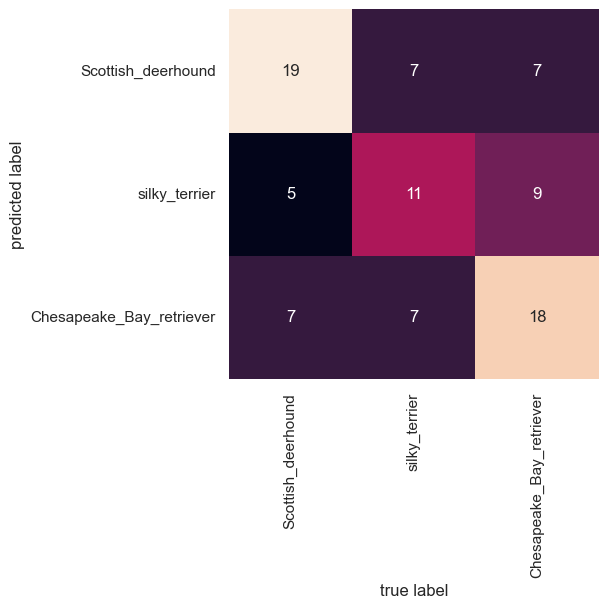

In [34]:
from sklearn.metrics import confusion_matrix
import seaborn as sns; sns.set()
mat = confusion_matrix(yb_test, yfit)
sns.heatmap(mat.T, square=True, annot=True, fmt='d', cbar=False,
            xticklabels=target_names,
            yticklabels=target_names)
plt.xlabel('true label')
plt.ylabel('predicted label');

# Testing Convolutional Neural Networks

Now we will test how Convolutional Neural Networks will manage to classify the same set of images. First we have to load the data:

In [35]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from sklearn.preprocessing import LabelEncoder

In [36]:
X_cnn, y_cnn = preprocess_data(path_to_data = "data", img_size = 64, n_class = 3, n_samples_in_class = 150, crop = True, flatten = False)

In [37]:
X_cnn.shape, y_cnn.shape

((450, 64, 64, 3), (450,))

In [38]:
X_cnn_train, X_cnn_test , y_cnn_train, y_cnn_test = train_test_split(X_cnn, y_cnn, test_size = 0.2, random_state = 44)

In [39]:
from preprocessing import expand_dataset

Now we will expand the dataset.

In [40]:
X_cnn_train, y_cnn_train = expand_dataset(X_cnn_train, y_cnn_train)

Converting images to tensors.

In [41]:
X_cnn_train_tensor = torch.tensor(X_cnn_train, dtype=torch.float32)
X_cnn_train_tensor = X_cnn_train_tensor.permute(0, 3, 1, 2)

X_cnn_test_tensor = torch.tensor(X_cnn_test, dtype=torch.float32)
X_cnn_test_tensor = X_cnn_test_tensor.permute(0, 3, 1, 2)

In [42]:
le = LabelEncoder()

y_cnn_train_tensor = le.fit_transform(y_cnn_train)
y_cnn_test_tensor = le.transform(y_cnn_test)
y_cnn_train_tensor = torch.tensor(y_cnn_train_tensor, dtype=torch.long)
y_cnn_test_tensor = torch.tensor(y_cnn_test_tensor, dtype=torch.long)

Now we will create the Convolutional Network. 

In this case CNN has the following structure:
$$
64 \times 64 \times 3
\;\xrightarrow{\text{$5\times5$ conv, 6 filters}}\;
60 \times 60 \times 6
\;\xrightarrow{\text{ReLU}}\;
60 \times 60 \times 6
\;\xrightarrow{\text{$2\times2$ max pool}}\;
30 \times 30 \times 6
\;\xrightarrow{\text{$5\times5$ conv, 16 filters}}\;
26 \times 26 \times 16
$$
$$
\;\xrightarrow{\text{ReLU}}\;
26 \times 26 \times 16
\;\xrightarrow{\text{$2\times2$ max pool}}\;
13 \times 13 \times 16
\;\xrightarrow{\text{flatten}}\;
2704
\;\xrightarrow{\text{FC 120 + ReLU}}\;
120
\;\xrightarrow{\text{FC 84 + ReLU}}\;
84
\;\xrightarrow{\text{FC 3}}\;
3
$$

In [55]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 13 * 13, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 3)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 16 * 13 * 13)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x


net = Net()

Now we need to define Loss function and optimizer.

In [56]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    net.parameters(),
    lr=0.001
)

In the next step we will train our CNN in 50 epochs.

In [57]:
for epoch in range(200):

    optimizer.zero_grad()

    outputs = net(X_cnn_train_tensor)
    loss = criterion(outputs, y_cnn_train_tensor)
    loss.backward()
    optimizer.step()

    print(f"epoch={epoch+1}, loss={loss.item():.4f}")

print('Finished Training')

epoch=1, loss=1.9161
epoch=2, loss=2.8571
epoch=3, loss=2.8369
epoch=4, loss=1.4670
epoch=5, loss=1.2630
epoch=6, loss=1.3015
epoch=7, loss=1.2428
epoch=8, loss=1.1638
epoch=9, loss=1.1075
epoch=10, loss=1.0777
epoch=11, loss=1.0701
epoch=12, loss=1.0678
epoch=13, loss=1.0686
epoch=14, loss=1.0659
epoch=15, loss=1.0585
epoch=16, loss=1.0509
epoch=17, loss=1.0437
epoch=18, loss=1.0351
epoch=19, loss=1.0245
epoch=20, loss=1.0119
epoch=21, loss=0.9951
epoch=22, loss=0.9764
epoch=23, loss=0.9534
epoch=24, loss=0.9247
epoch=25, loss=0.8929
epoch=26, loss=0.8560
epoch=27, loss=0.8165
epoch=28, loss=0.7795
epoch=29, loss=0.7378
epoch=30, loss=0.6909
epoch=31, loss=0.6424
epoch=32, loss=0.6081
epoch=33, loss=0.5962
epoch=34, loss=0.5548
epoch=35, loss=0.5022
epoch=36, loss=0.4991
epoch=37, loss=0.4352
epoch=38, loss=0.4253
epoch=39, loss=0.3655
epoch=40, loss=0.3710
epoch=41, loss=0.3434
epoch=42, loss=0.2900
epoch=43, loss=0.2913
epoch=44, loss=0.2395
epoch=45, loss=0.2332
epoch=46, loss=0.19

Let's see what the accuracy of the model is.

In [58]:
correct = 0
total = 0
with torch.no_grad():
    outputs = net(X_cnn_test_tensor)
    _, predicted = torch.max(outputs.data, 1)
    total += y_cnn_test_tensor.size(0)
    correct += (predicted == y_cnn_test_tensor).sum().item()

print(f'Accuracy of the network on the {X_cnn_test_tensor.shape[0]} test images: %d %%' % (
    100 * correct / total))

Accuracy of the network on the 90 test images: 56 %
